## 0) Phát biểu bài toán

### Mục tiêu

Phân tích dữ liệu tai nghe nhằm khảo sát **tính khả thi** cho việc xây dựng mô hình dự đoán biến mục tiêu (target variable) **Y** từ các biến/đặc trưng (predictors/features) **Xᵢ** (i = 1..N).

### Xác định biến mục tiêu và loại bài toán

- **Y (target)**: `price_vnd` (giá – biến số liên tục).
- Vì **Y là biến số (thực)** ⇒ bài toán mô hình hoá phù hợp là **Hồi quy (Regression)**.

### Bài toán có khả thi (về dữ liệu) không? Vì sao?

- **Khả thi** vì dataset sau crawl/merge/clean có:
  - **Số lượng mẫu đủ lớn** (hàng trăm đến >1000 sản phẩm) để làm EDA và thử mô hình cơ bản.
  - **Y có sẵn** (đã loại bản ghi thiếu giá/giá = 0 trong bước cleaning).
  - **Các X có ý nghĩa thực tế** và có thể chuẩn hoá/giảm missing (connection, pin, khối lượng, cờ wireless/mic/gaming...).
- **Hạn chế cần nêu khi báo cáo**:
  - Spec giữa các website không đồng nhất ⇒ có missing/khác chuẩn, cần impute/`Unknown`.
  - Một số thông số có thể suy ra từ tên/URL (wireless/type/connection) ⇒ có rủi ro sai lệch nhỏ.

### Nếu khả thi, các đặc trưng hữu ích để dự đoán giá là gì?

Các feature (X) có thể dùng cho mô hình/EDA:

- **Nhóm nhận diện sản phẩm**: `brand`, `type`.
- **Nhóm kết nối & công nghệ**: `connection`, `is_wireless`, `has_mic`, `is_gaming`.
- **Nhóm thông số kỹ thuật**: `battery_life_hours`, `weight_gram`.

> Gợi ý khi báo cáo: có thể ưu tiên các biến liên quan trực tiếp trải nghiệm/độ “cao cấp” (brand, wireless, pin, trọng lượng, loại tai nghe, chuẩn kết nối) vì chúng thường tác động mạnh đến giá.

---


# 01 - Thu thập dữ liệu (Web Crawling) – Tai nghe / Headphone

## Mục tiêu dữ liệu

- **Đơn vị quan sát**: 1 sản phẩm tai nghe.
- **Nguồn dữ liệu**: dữ liệu tự thu thập bằng script crawl.
- **Y (target)**: `price_vnd`.
- **X (features)**: `brand`, `type`, `is_wireless`, `has_mic`, `connection`, `battery_life_hours`, `weight_gram`, `is_gaming`.

## Cấu trúc project liên quan

- `scripts/`: các script crawl/merge.
- `raw_data/`: file CSV raw theo từng nguồn (có timestamp).
- `clean_data/`: dữ liệu sau khi cleaning.

---

## 1) CellphoneS (`cellphones.com.vn`)

### Danh sách sản phẩm (listing)

- Kết hợp 2 hướng:
  - Crawl các trang danh mục (requests + BeautifulSoup).
  - Crawl trang **search** theo nhiều từ khóa bằng **Selenium** để nhấn nút "Xem thêm" và load thêm sản phẩm.

### Trang chi tiết (detail)

- Nhiều thông số (đặc biệt `connection`) nằm trong modal **"Thông số kĩ thuật"**.
- Dùng Selenium vào trang detail và bấm **"Xem tất cả"** để mở modal rồi parse bảng.

### Script

- `scripts/crawl_cellphones_headphone.py`
- Output: `raw_data/headphone_cellphones_<timestamp>.csv`

---

## 2) GearVN (`gearvn.com`)

### Danh sách sản phẩm (listing)

- Dùng Selenium vào trang search, nhấn **"Xem thêm sản phẩm"** (`#load_more_search`).

### Trang chi tiết (detail)

- Thông số đầy đủ nằm trong modal khi bấm **"Xem cấu hình chi tiết"** (`#gvn-specs-core-btn`).
- Dùng Selenium bấm nút mở modal, parse bảng `<th>/<td>`.

### Script

- `scripts/crawl_gearvn_headphone.py`
- Output: `raw_data/headphone_gearvn_<timestamp>.csv`

---

## 3) Phong Vũ (`phongvu.vn`)

### Danh sách sản phẩm (listing)

- Load động, dùng Selenium click **"Xem thêm sản phẩm"**.
- Sau đó lọc chỉ giữ sản phẩm tai nghe theo URL/tên.

### Trang chi tiết (detail)

- Spec render JS, dùng Selenium cho detail để lấy HTML đã render.
- Parse cặp `label/value` trong section "Thông tin chi tiết".

### Script

- `scripts/crawl_phongvu_headphone.py`
- Output: `raw_data/headphone_phongvu_<timestamp>.csv`

---

## 4) Hoàng Hà Mobile (`hoanghamobile.com`)

### Danh sách sản phẩm (listing)

- Crawl trang search `tim-kiem?kwd=tai+nghe` (nhiều trang `p=2,3,...`).
- Lọc URL đúng dạng `/tai-nghe/<slug>` (loại `/kho-san-pham-cu/`, `/tra-gop/`, ...).

### Trang chi tiết (detail)

- Bảng spec đầy đủ nằm trong popup khi bấm **"Xem cấu hình chi tiết"**.
- Không cần Selenium: lấy endpoint `Ajax/fullspecs2/<id>` từ HTML detail.
- Gọi endpoint với header `X-Requested-With` + `Referer`, parse HTML trả về.

### Script

- `scripts/crawl_hoanghamobile_headphone.py`
- Output: `raw_data/headphone_hoanghamobile_<timestamp>.csv`

---

## 5) Gộp dữ liệu raw

- Nối các file raw theo từng nguồn, drop trùng theo `url`.
- Script: `scripts/merge_raw_to_raw_data.py` (có thể cập nhật để thêm Hoàng Hà Mobile nếu cần).




## 6) Công nghệ sử dụng (tổng quan)

Để crawl dữ liệu từ trang TMĐT có nội dung động, dự án dùng kết hợp:

- **Selenium**: điều khiển trình duyệt như người dùng thật (scroll, click nút `Xem thêm`, mở modal cấu hình/technical).
- **Undetected-Chromedriver (uc)**: giảm khả năng bị chặn khi chạy bot.
- **BeautifulSoup + Regex**: trích xuất trường dữ liệu từ HTML (label/value, bảng `<th>/<td>`, định dạng chuỗi).
- **requests** (khi có endpoint/AJAX): gọi thẳng URL lấy full spec để nhanh và ổn định hơn.
- **Pandas**: chuẩn hoá + lưu output CSV theo từng nguồn, sau đó phục vụ bước merge/clean.

## 7) Kết quả thu thập (dùng cho báo cáo)

- Mỗi dòng đại diện cho **1 sản phẩm tai nghe**.
- Các thông số quan trọng (đủ điều kiện đưa vào mô hình dự đoán giá) được cố gắng trích từ trang detail, bao gồm:
  - `connection`
  - `battery_life_hours`
  - `weight_gram`
  - `type`, `is_wireless`, `has_mic`, `is_gaming` (theo keyword/suy luận khi cần)

> Số lượng mẫu cuối cùng sẽ được thống kê tự động ở cell code bên dưới dựa trên các file `raw_data/headphone_*.csv` bạn đã crawl.

## 8) Quy tắc lọc/loại dữ liệu rác

- Chỉ giữ URL/sản phẩm có dấu hiệu là **tai nghe/headphone**.
- Loại các đường link rác/không phải sản phẩm (ví dụ: `/kho-san-pham-cu/`, `/tra-gop/`, `các trang tìm kiếm/paging không phải detail`…).
- Chuẩn hoá URL trước khi merge để tránh trùng bản ghi.


raw_data base: c:\Study\KHDL\GK\de_tai_2_headphone\raw_data
                                          file  n_rows  n_unique_url
0     headphone_cellphones_20260317_152100.csv     723           723
2  headphone_hoanghamobile_20260317_144138.csv     279           279
3        headphone_phongvu_20260317_133054.csv     125           125
1         headphone_gearvn_20260317_145811.csv      63            63

Tổng số dòng raw (ước tính): 1190


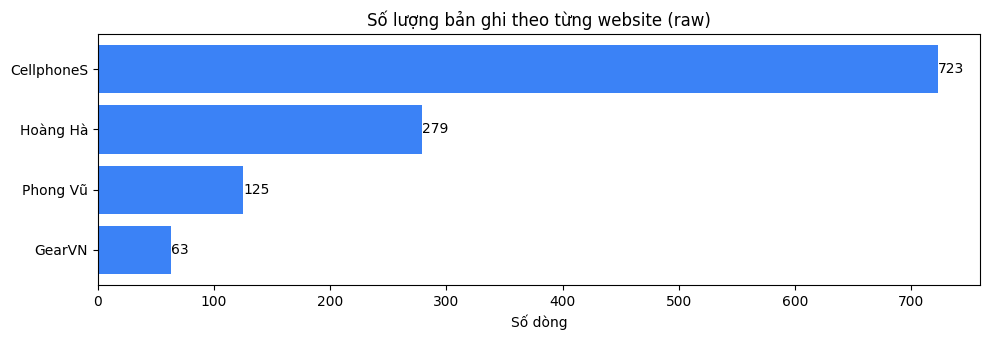

In [1]:
# Thống kê số lượng bản ghi theo từng file raw (để lấy số liệu cho slide)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Ưu tiên đường dẫn dự án (absolute) để chạy ổn định dù working directory thay đổi
candidate_bases = [
    Path(r"c:\Study\KHDL\GK\de_tai_2_headphone\raw_data"),
    Path("../raw_data"),
    Path("raw_data"),
]

base = None
for b in candidate_bases:
    if b.exists() and b.is_dir():
        base = b
        break

if base is None:
    raise FileNotFoundError(
        "Không tìm thấy thư mục raw_data. Hãy đảm bảo bạn chạy notebook từ đúng project và có folder raw_data/."
    )

raw_files = sorted(base.glob("headphone_*.csv"))
# loại trường hợp nếu có raw_data.csv (không match vì pattern headphone_*, nhưng để chắc chắn)
raw_files = [p for p in raw_files if p.name != "raw_data.csv"]

rows = []
for p in raw_files:
    try:
        df_tmp = pd.read_csv(p)
        n_rows = len(df_tmp)
        n_unique_url = None
        if "url" in df_tmp.columns:
            n_unique_url = df_tmp["url"].nunique(dropna=True)
        rows.append({"file": p.name, "n_rows": n_rows, "n_unique_url": n_unique_url})
    except Exception as e:
        rows.append({"file": p.name, "n_rows": None, "n_unique_url": None})

stats = pd.DataFrame(rows).sort_values("n_rows", ascending=False)
print("raw_data base:", base)
print(stats)

# Tổng hợp
valid = stats[stats["n_rows"].notna()].copy()

total_rows = int(valid["n_rows"].sum()) if len(valid) else 0
print("\nTổng số dòng raw (ước tính):", total_rows)

# Vẽ bar chart (đẹp hơn cho slide)
if len(valid):
    # Rút gọn nhãn file -> tên website
    def short_web_label(fname: str) -> str:
        n = fname.lower()
        if "cellphones" in n:
            return "CellphoneS"
        if "gearvn" in n:
            return "GearVN"
        if "phongvu" in n:
            return "Phong Vũ"
        if "hoanghamobile" in n:
            return "Hoàng Hà"
        return fname.replace("headphone_", "").replace(".csv", "")

    valid = valid.copy()
    valid["web"] = valid["file"].astype(str).apply(short_web_label)

    # Có thể trùng tên web nếu nhiều timestamp; gộp theo web
    valid_web = valid.groupby("web", as_index=False)["n_rows"].sum().sort_values("n_rows", ascending=False)

    plt.figure(figsize=(10, 3.5))
    plt.barh(valid_web["web"], valid_web["n_rows"].astype(int), color="#3b82f6")
    plt.xlabel("Số dòng")
    plt.ylabel("")
    plt.title("Số lượng bản ghi theo từng website (raw)")

    # Viết số lên đầu mỗi thanh
    for i, (val, web) in enumerate(zip(valid_web["n_rows"], valid_web["web"])):
        plt.text(val, i, f"{int(val)}", va="center", ha="left", fontsize=10)

    plt.gca().invert_yaxis()  # giữ thứ tự từ cao -> thấp
    plt.tight_layout()
    plt.show()


## 9) Biểu đồ dữ liệu crawl theo từng website

Code dưới đây sẽ:
- Đọc từng file raw `headphone_<web>_<timestamp>.csv` trong `raw_data/`
- Vẽ 2 biểu đồ cho từng web:
  - Top brand (số lượng sản phẩm)
  - Phân bố giá (`price_vnd`, đổi sang triệu VND)
- Lưu ảnh vào `figures/data_crawl/` để bạn chèn trực tiếp vào slide.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6704\4093872359.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


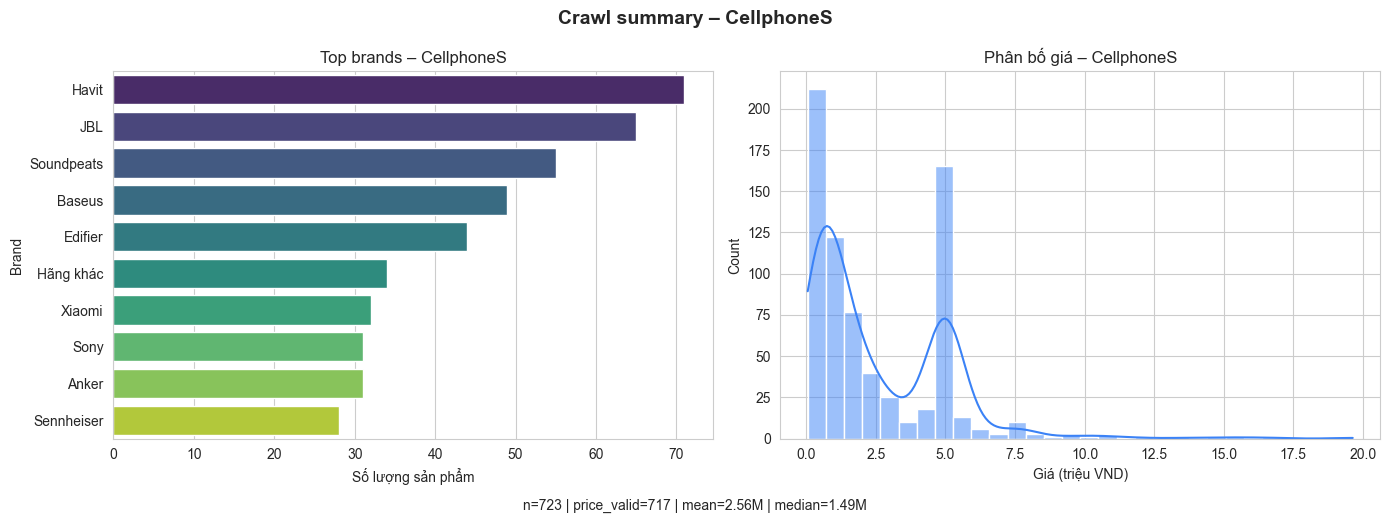

Saved: c:\Study\KHDL\GK\de_tai_2_headphone\figures\data_crawl\crawl_summary_CellphoneS_headphone_cellphones_20260317_152100.png


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6704\4093872359.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


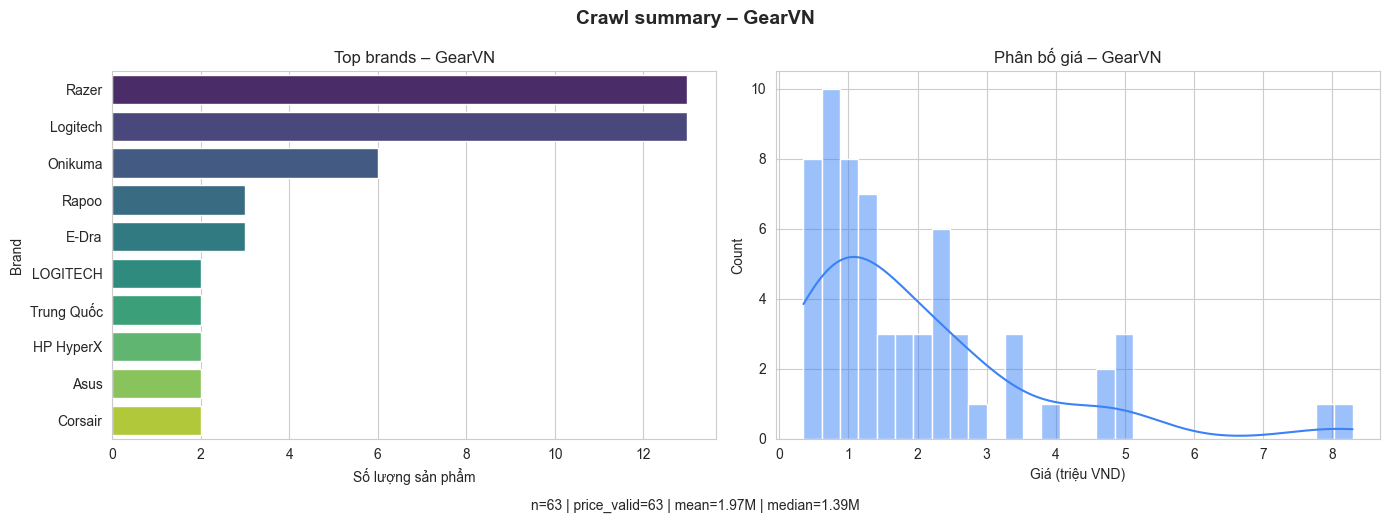

Saved: c:\Study\KHDL\GK\de_tai_2_headphone\figures\data_crawl\crawl_summary_GearVN_headphone_gearvn_20260317_145811.png


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6704\4093872359.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


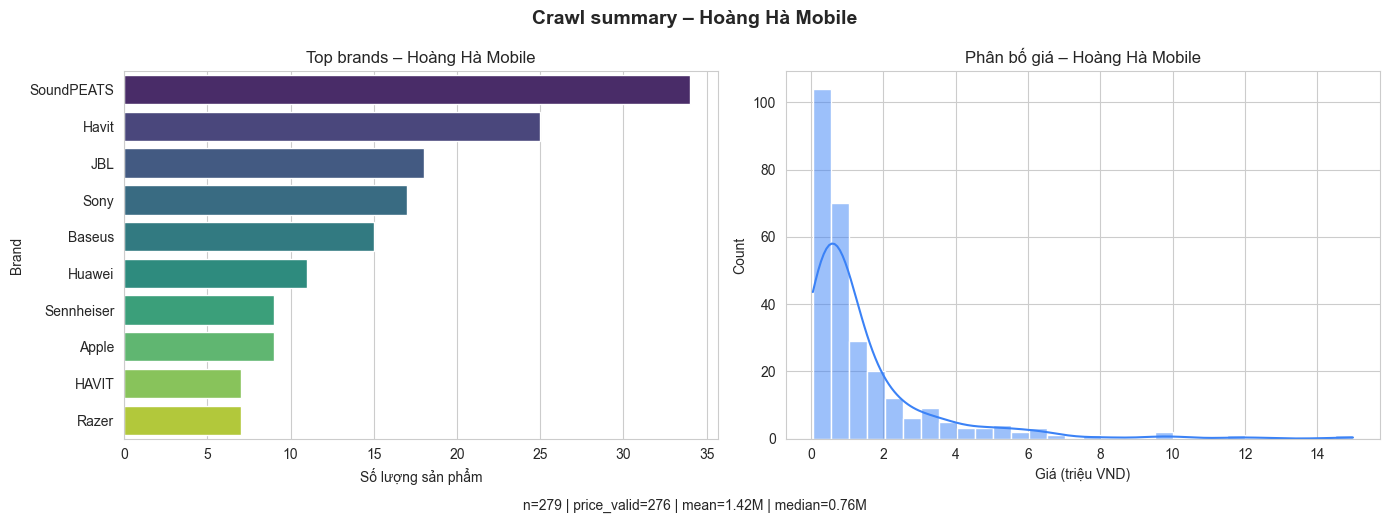

Saved: c:\Study\KHDL\GK\de_tai_2_headphone\figures\data_crawl\crawl_summary_Hoàng_Hà_Mobile_headphone_hoanghamobile_20260317_144138.png


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6704\4093872359.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


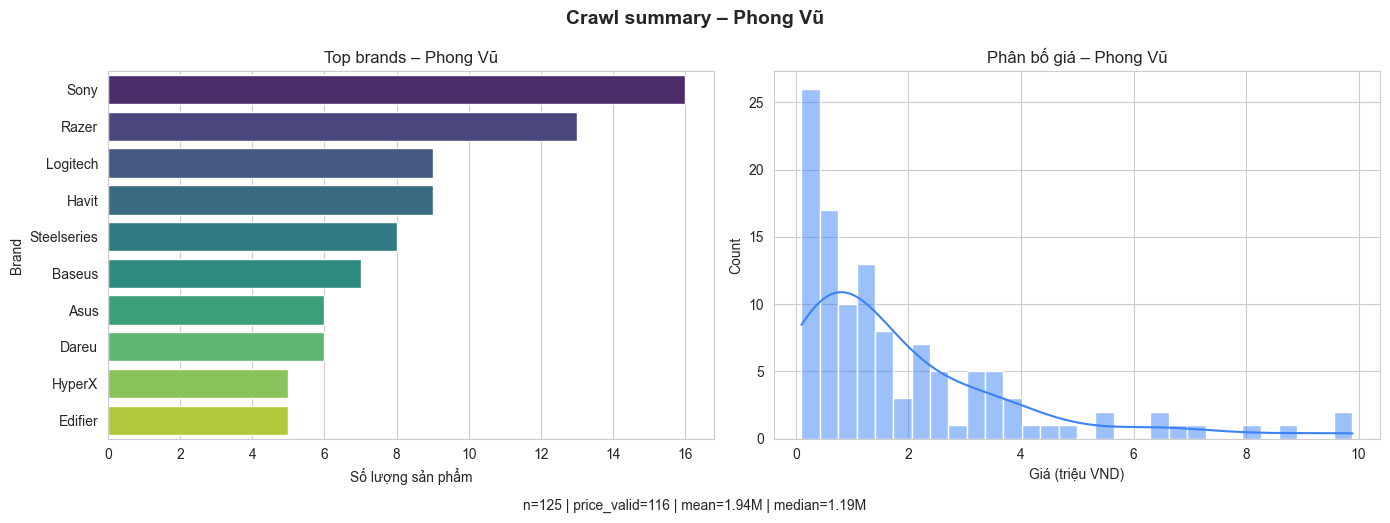

Saved: c:\Study\KHDL\GK\de_tai_2_headphone\figures\data_crawl\crawl_summary_Phong_Vũ_headphone_phongvu_20260317_133054.png


In [2]:
# Vẽ biểu đồ crawl theo từng website

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

base = Path(r"c:\Study\KHDL\GK\de_tai_2_headphone\raw_data")
out_dir = Path(r"c:\Study\KHDL\GK\de_tai_2_headphone\figures\data_crawl")
out_dir.mkdir(parents=True, exist_ok=True)

files = sorted(base.glob("headphone_*.csv"))

def web_label_from_filename(name: str):
    n = name.lower()
    if "cellphones" in n:
        return "CellphoneS"
    if "gearvn" in n:
        return "GearVN"
    if "phongvu" in n:
        return "Phong Vũ"
    if "hoanghamobile" in n:
        return "Hoàng Hà Mobile"
    return name

price_col_candidates = ["price_vnd", "price_raw"]

for p in files:
    try:
        df_tmp = pd.read_csv(p)
    except Exception as e:
        print("Skip (read error):", p, e)
        continue

    web = web_label_from_filename(p.name)

    # brand
    if "brand" in df_tmp.columns:
        brand_series = df_tmp["brand"].fillna("Unknown").astype(str)
    else:
        brand_series = pd.Series(["Unknown"] * len(df_tmp))

    top_brands = brand_series.value_counts().head(10)

    # price
    price_col = next((c for c in price_col_candidates if c in df_tmp.columns), None)
    if price_col is None:
        print("Skip (no price col):", p)
        continue

    df_tmp[price_col] = pd.to_numeric(df_tmp[price_col], errors="coerce")
    price = df_tmp[price_col].dropna()

    # filter giá không hợp lệ (nếu có)
    price = price[price > 0]
    df_plot = df_tmp[df_tmp[price_col].notna() & (pd.to_numeric(df_tmp[price_col], errors="coerce") > 0)].copy()

    if len(df_plot) == 0:
        print("Skip (no valid price):", p)
        continue

    df_plot["price_million"] = pd.to_numeric(df_plot[price_col], errors="coerce") / 1e6

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Top brand
    sns.barplot(
        x=top_brands.values,
        y=top_brands.index,
        ax=axes[0],
        palette="viridis",
    )
    axes[0].set_title(f"Top brands – {web}")
    axes[0].set_xlabel("Số lượng sản phẩm")
    axes[0].set_ylabel("Brand")

    # Price distribution
    sns.histplot(df_plot["price_million"], bins=30, kde=True, ax=axes[1], color="#3b82f6")
    axes[1].set_title(f"Phân bố giá – {web}")
    axes[1].set_xlabel("Giá (triệu VND)")
    axes[1].set_ylabel("Count")

    # Summary text
    summary = {
        "n_rows": len(df_tmp),
        "n_price": len(price),
        "mean_price_m": float(df_plot["price_million"].mean()),
        "median_price_m": float(df_plot["price_million"].median()),
        "min_price_m": float(df_plot["price_million"].min()),
        "max_price_m": float(df_plot["price_million"].max()),
    }

    fig.suptitle(f"Crawl summary – {web}", fontsize=14, fontweight="bold")
    fig.text(
        0.5,
        -0.02,
        f"n={summary['n_rows']} | price_valid={summary['n_price']} | mean={summary['mean_price_m']:.2f}M | median={summary['median_price_m']:.2f}M",
        ha="center",
        fontsize=10,
    )

    plt.tight_layout()

    out_path = out_dir / f"crawl_summary_{web.replace(' ', '_')}_{p.stem}.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


Rows: 1190 | Cols: 14


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6704\864043833.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, ax=axes[1], palette="Set2")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6704\864043833.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, ax=axes[5], palette="Set3")


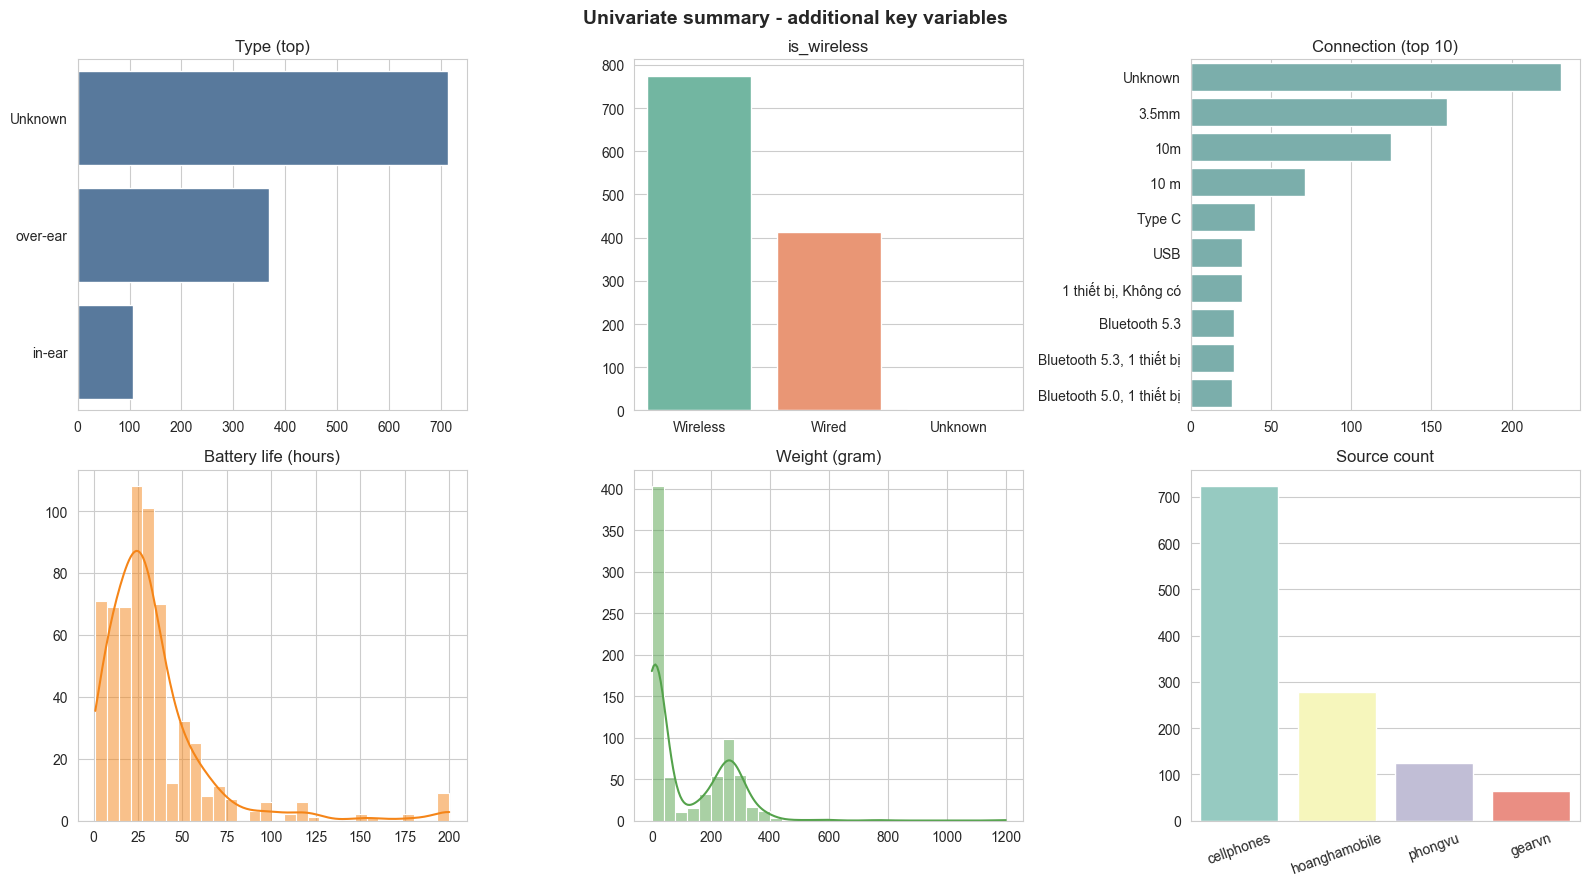

Saved: c:\Study\KHDL\GK\de_tai_2_headphone\figures\data_crawl\univariate_additional_variables.png


In [ ]:
# Biểu đồ bổ sung cho các biến quan trọng (đơn biến)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

base = Path(r"c:\Study\KHDL\GK\de_tai_2_headphone\raw_data")
out_dir = Path(r"c:\Study\KHDL\GK\de_tai_2_headphone\figures\data_crawl")
out_dir.mkdir(parents=True, exist_ok=True)

raw_files = sorted(base.glob("headphone_*.csv"))
if not raw_files:
    raise FileNotFoundError("Không tìm thấy file raw headphone_*.csv")

dfs = []
for p in raw_files:
    try:
        tmp = pd.read_csv(p)
        tmp["__file__"] = p.name
        dfs.append(tmp)
    except Exception:
        pass

if not dfs:
    raise RuntimeError("Không đọc được file raw nào")

df_all = pd.concat(dfs, ignore_index=True)
print("Rows:", len(df_all), "| Cols:", df_all.shape[1])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 1) type
if "type" in df_all.columns:
    vc = df_all["type"].fillna("Unknown").astype(str).value_counts().head(10)
    sns.barplot(x=vc.values, y=vc.index, ax=axes[0], color="#4c78a8")
    axes[0].set_title("Type (top)")

# 2) is_wireless
if "is_wireless" in df_all.columns:
    s = pd.to_numeric(df_all["is_wireless"], errors="coerce").fillna(-1).map({1: "Wireless", 0: "Wired", -1: "Unknown"})
    vc = s.value_counts()
    sns.barplot(x=vc.index, y=vc.values, ax=axes[1], palette="Set2")
    axes[1].set_title("is_wireless")

# 3) connection
if "connection" in df_all.columns:
    vc = df_all["connection"].fillna("Unknown").astype(str).value_counts().head(10)
    sns.barplot(x=vc.values, y=vc.index, ax=axes[2], color="#72b7b2")
    axes[2].set_title("Connection (top 10)")

# 4) battery_life_hours
if "battery_life_hours" in df_all.columns:
    b = pd.to_numeric(df_all["battery_life_hours"], errors="coerce")
    b = b[(b > 0) & (b <= 200)]
    sns.histplot(b, bins=30, kde=True, ax=axes[3], color="#f58518")
    axes[3].set_title("Battery life (hours)")

# 5) weight_gram
if "weight_gram" in df_all.columns:
    w = pd.to_numeric(df_all["weight_gram"], errors="coerce")
    w = w[(w > 0) & (w <= 2000)]
    sns.histplot(w, bins=30, kde=True, ax=axes[4], color="#54a24b")
    axes[4].set_title("Weight (gram)")

# 6) source
if "source" in df_all.columns:
    vc = df_all["source"].fillna("Unknown").astype(str).value_counts()
    sns.barplot(x=vc.index, y=vc.values, ax=axes[5], palette="Set3")
    axes[5].set_title("Source count")
    axes[5].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Univariate summary - additional key variables", fontsize=14, fontweight="bold")
plt.tight_layout()
out_path = out_dir / "univariate_additional_variables.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", out_path)
